In [1]:
import numpy as np 
import pandas as pd

In [4]:
data = pd.read_csv("ncr_ride_bookings.csv")

In [6]:
print(data.head())
print(data.info())
print(data.describe())
print(data.isnull().sum())


         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0  ...         

In [9]:
data.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [13]:
print(data.shape)
print(data.info())
print(data.isnull().sum())

(150000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by C

In [15]:
data.drop([
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason'
], axis=1, inplace=True)

In [18]:
data['Avg VTAT'] = data['Avg VTAT'].fillna(data['Avg VTAT'].mean())
data['Avg CTAT'] = data['Avg CTAT'].fillna(data['Avg CTAT'].mean())
data['Booking Value'] = data['Booking Value'].fillna(data['Booking Value'].median())
data['Ride Distance'] = data['Ride Distance'].fillna(data['Ride Distance'].median())
data['Driver Ratings'] = data['Driver Ratings'].fillna(data['Driver Ratings'].mean())
data['Customer Rating'] = data['Customer Rating'].fillna(data['Customer Rating'].mean())

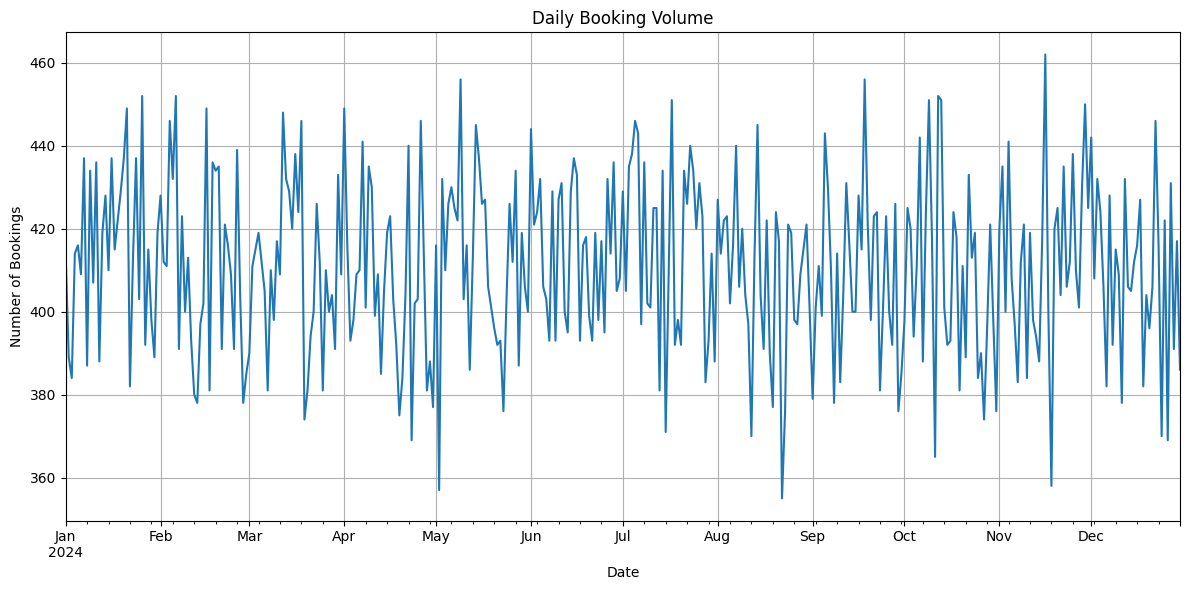

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize column names
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert 'date' column to datetime
data['date'] = pd.to_datetime(data['date'], errors='coerce')

# Group by date and count bookings
daily_counts = data.groupby('date').size()

# Plot daily booking volume
plt.figure(figsize=(12, 6))
daily_counts.plot()
plt.title('Daily Booking Volume')
plt.xlabel('Date')
plt.ylabel('Number of Bookings')
plt.grid(True)
plt.tight_layout()
plt.show()